In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("student_data.csv")
df.head()

,Student_ID,Gender,City,Study_Hours,Attendance,Marks,Passed
0,101,Male,Pune,5.0,90.0,85.0,Yes
1,102,Female,Mumbai,4.0,85.0,78.0,Yes
2,103,Male,Nashik,6.0,95.0,92.0,Yes
3,104,Female,Pune,NaN,88.0,75.0,Yes
4,105,Male,Mumbai,3.0,70.0,60.0,No


In [9]:
#Basic Information
df.shape

(15, 7)

In [4]:
df.columns

Index(['Student_ID', 'Gender', 'City', 'Study_Hours', 'Attendance', 'Marks',
       'Passed'],
      dtype='str')

In [5]:
df.dtypes

Student_ID       int64
Gender             str
City               str
Study_Hours    float64
Attendance     float64
Marks          float64
Passed             str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   15 non-null     int64  
 1   Gender       15 non-null     str    
 2   City         15 non-null     str    
 3   Study_Hours  13 non-null     float64
 4   Attendance   14 non-null     float64
 5   Marks        14 non-null     float64
 6   Passed       15 non-null     str    
dtypes: float64(3), int64(1), str(3)
memory usage: 1.1 KB


In [10]:
#Check Missing Values
df.isnull().sum()

Student_ID     0
Gender         0
City           0
Study_Hours    2
Attendance     1
Marks          1
Passed         0
dtype: int64

In [11]:
#Handle Missing Values

In [12]:
df['Study_Hours'] = df['Study_Hours'].fillna(df['Study_Hours'].median())

df['Attendance'] = df['Attendance'].fillna(df['Attendance'].median())

df['Marks'] = df['Marks'].fillna(df['Marks'].median())

In [13]:
df

,Student_ID,Gender,City,Study_Hours,Attendance,Marks,Passed
0,101,Male,Pune,5.0,90.0,85.0,Yes
1,102,Female,Mumbai,4.0,85.0,78.0,Yes
2,103,Male,Nashik,6.0,95.0,92.0,Yes
3,104,Female,Pune,5.0,88.0,75.0,Yes
4,105,Male,Mumbai,3.0,70.0,60.0,No
5,106,Female,Nashik,7.0,98.0,96.0,Yes
6,107,Male,Pune,2.0,65.0,55.0,No
7,108,Female,Mumbai,5.0,86.0,80.0,Yes
8,109,Male,Nashik,4.0,82.0,72.0,Yes
9,110,Female,Pune,3.0,75.0,68.0,No


In [14]:
df.isnull().sum()

Student_ID     0
Gender         0
City           0
Study_Hours    0
Attendance     0
Marks          0
Passed         0
dtype: int64

In [15]:
#Statistical Summary

In [16]:
df.describe()

,Student_ID,Study_Hours,Attendance,Marks
count,15.000000,15.000000,15.000000,15.000000
mean,108.000000,4.666667,83.466667,76.300000
std,4.472136,1.718249,11.654960,14.389728
min,101.000000,2.000000,60.000000,50.000000
25%,104.500000,3.500000,77.500000,69.000000
50%,108.000000,5.000000,86.000000,76.500000
75%,111.500000,5.500000,91.000000,87.000000
max,115.000000,8.000000,99.000000,98.000000


In [17]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(0)

In [18]:
df.drop_duplicates(inplace=True)

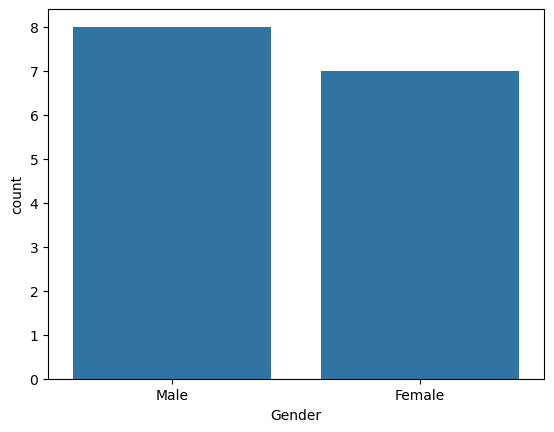

In [19]:
#Univariate Analysis

sns.countplot(x='Gender', data=df)
plt.show()

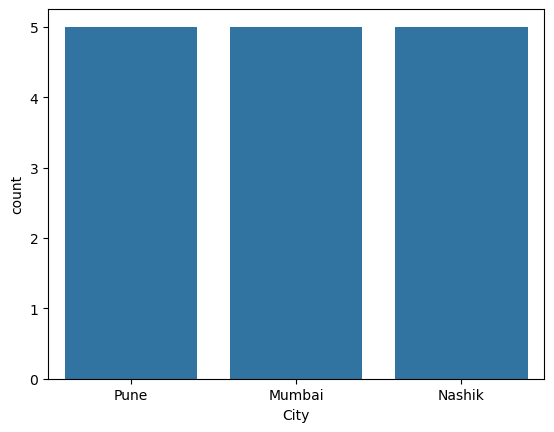

In [20]:
sns.countplot(x='City', data=df)
plt.show()

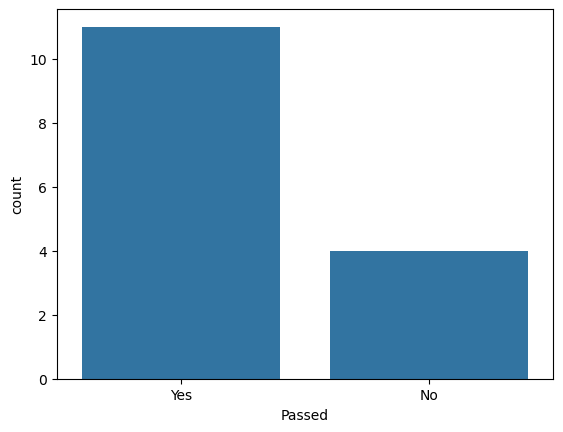

In [21]:
sns.countplot(x='Passed', data=df)
plt.show()

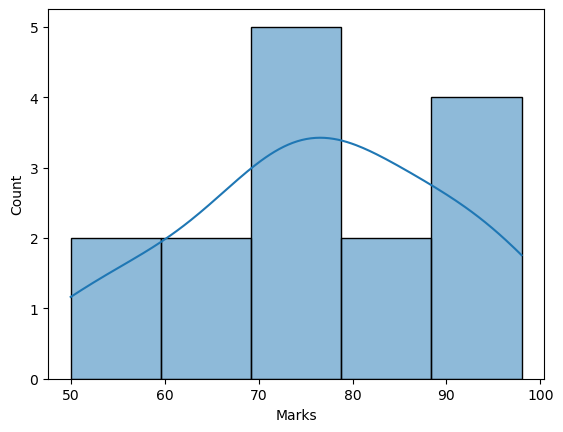

In [22]:
sns.histplot(df['Marks'], kde=True)
plt.show()

In [23]:
# Bivariate Analysis

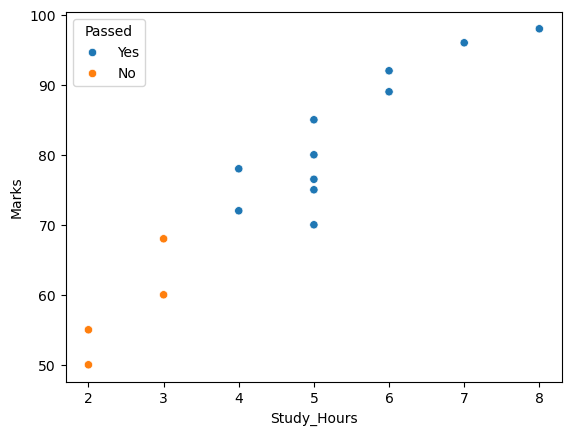

In [24]:
# Study Hours vs Marks
sns.scatterplot(x='Study_Hours',
                y='Marks',
                hue='Passed',
                data=df)

plt.show()

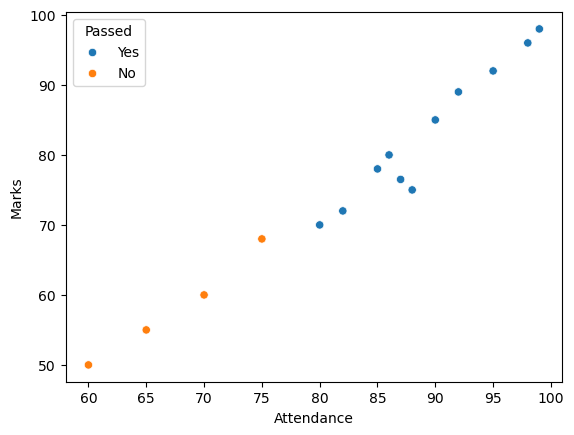

In [25]:
sns.scatterplot(x='Attendance',
                y='Marks',
                hue='Passed',
                data=df)

plt.show()

In [26]:
#Correlation Analysis

num_df = df[['Study_Hours',
             'Attendance',
             'Marks']]

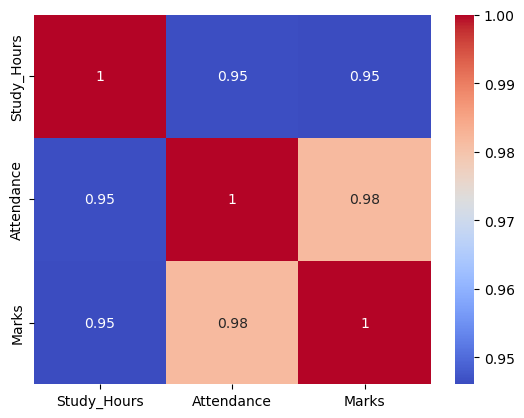

In [27]:
sns.heatmap(num_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

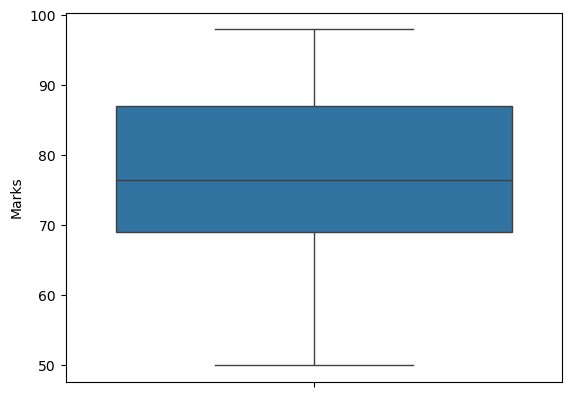

In [28]:
#Outlier Detection
sns.boxplot(df['Marks'])
plt.show()

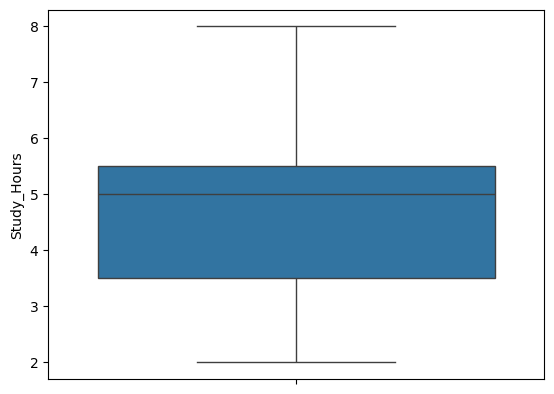

In [29]:
sns.boxplot(df['Study_Hours'])
plt.show()

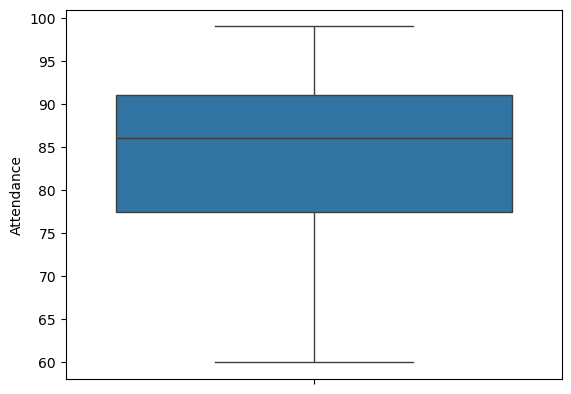

In [30]:
sns.boxplot(df['Attendance'])
plt.show()

In [31]:
#Feature Selection

In [32]:
#Remove Student_ID because it doesn't help prediction.

df.drop('Student_ID',
        axis=1,
        inplace=True)

In [33]:
#Encoding

In [34]:
#Machine Learning models cannot understand text.

df['Gender'] = df['Gender'].map({
    'Male':0,
    'Female':1
})

In [35]:
df

,Gender,City,Study_Hours,Attendance,Marks,Passed
0,0,Pune,5.0,90.0,85.0,Yes
1,1,Mumbai,4.0,85.0,78.0,Yes
2,0,Nashik,6.0,95.0,92.0,Yes
3,1,Pune,5.0,88.0,75.0,Yes
4,0,Mumbai,3.0,70.0,60.0,No
5,1,Nashik,7.0,98.0,96.0,Yes
6,0,Pune,2.0,65.0,55.0,No
7,1,Mumbai,5.0,86.0,80.0,Yes
8,0,Nashik,4.0,82.0,72.0,Yes
9,1,Pune,3.0,75.0,68.0,No


In [36]:
df['Passed'] = df['Passed'].map({
    'No':0,
    'Yes':1
})

In [37]:
df

,Gender,City,Study_Hours,Attendance,Marks,Passed
0,0,Pune,5.0,90.0,85.0,1
1,1,Mumbai,4.0,85.0,78.0,1
2,0,Nashik,6.0,95.0,92.0,1
3,1,Pune,5.0,88.0,75.0,1
4,0,Mumbai,3.0,70.0,60.0,0
5,1,Nashik,7.0,98.0,96.0,1
6,0,Pune,2.0,65.0,55.0,0
7,1,Mumbai,5.0,86.0,80.0,1
8,0,Nashik,4.0,82.0,72.0,1
9,1,Pune,3.0,75.0,68.0,0


In [38]:
#One Hot Encoding

df = pd.get_dummies(df,
                    columns=['City'],
                    drop_first=True)

In [39]:
df

,Gender,Study_Hours,Attendance,Marks,Passed,City_Nashik,City_Pune
0,0,5.0,90.0,85.0,1,False,True
1,1,4.0,85.0,78.0,1,False,False
2,0,6.0,95.0,92.0,1,True,False
3,1,5.0,88.0,75.0,1,False,True
4,0,3.0,70.0,60.0,0,False,False
5,1,7.0,98.0,96.0,1,True,False
6,0,2.0,65.0,55.0,0,False,True
7,1,5.0,86.0,80.0,1,False,False
8,0,4.0,82.0,72.0,1,True,False
9,1,3.0,75.0,68.0,0,False,True


In [40]:
#Separate X and y

X = df.drop('Passed',
            axis=1)

y = df['Passed']

In [42]:
print(X)

    Gender  Study_Hours  Attendance  Marks  City_Nashik  City_Pune
0        0          5.0        90.0   85.0        False       True
1        1          4.0        85.0   78.0        False      False
2        0          6.0        95.0   92.0         True      False
3        1          5.0        88.0   75.0        False       True
4        0          3.0        70.0   60.0        False      False
5        1          7.0        98.0   96.0         True      False
6        0          2.0        65.0   55.0        False       True
7        1          5.0        86.0   80.0        False      False
8        0          4.0        82.0   72.0         True      False
9        1          3.0        75.0   68.0        False       True
10       0          8.0        99.0   98.0        False      False
11       1          6.0        92.0   89.0         True      False
12       0          5.0        80.0   70.0        False       True
13       1          2.0        60.0   50.0        False      F

In [43]:
print(y)

0     1
1     1
2     1
3     1
4     0
5     1
6     0
7     1
8     1
9     0
10    1
11    1
12    1
13    0
14    1
Name: Passed, dtype: int64


In [44]:
#Train-Test Split

from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
#Meaning:

# 80% Training
# 20% Testing

In [48]:
#Feature Scaling**

In [49]:
#mportant for Logistic Regression.

In [50]:
from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [52]:
#Train Logistic Regression Model

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
model = LogisticRegression()

model.fit(X_train,
          y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [55]:
y_pred = model.predict(X_test)

In [56]:
print(y_pred)

[1 1 1]


In [57]:
from sklearn.metrics import accuracy_score

In [58]:
accuracy_score(y_test,
               y_pred)

0.6666666666666666